In [178]:
from typing import List, Dict
from copy import deepcopy
from functools import partial
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import pyscf
from openfermion import MolecularData
from openfermion.chem import geometry_from_pubchem
from openfermionpyscf import run_pyscf
import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.primitives import BitArray
from qiskit_aer import AerSimulator  # For MPS Simulator.
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import qasm2, qasm3
from qiskit.visualization import timeline_drawer
from qiskit.visualization.timeline.stylesheet import IQXStandard, IQXSimple, IQXDebugging
import qiskit_ibm_runtime
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_addon_sqd.fermion import SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch
import ffsim
from remove_idle import remove_idle, merge_idle_bits
from change_qubits import map_qubits, qubits_from_regsiter

In [179]:
use_initial_measurement: bool = True
use_dd: bool = True

In [180]:
ibm_computer: str = "ibm_fez"
computer = ibm_computer
# qubits = list(range(90))
# qubits.remove(46)
# qubits.remove(85)
# qubits = [56, 60, 61, 62, 63, 76] + [65, 66, 67, 68, 69] + [77, 78] + list(range(80, 156))
qubits = list(range(73))
# qubits.remove(85)
qubits.remove(46)
# qubits = list(range(36))
nshots: int = 500_000

nqubits = len(qubits)
nqubits

72

In [181]:
fragment = "atp_0_be2_f14"

adapt_iterations: int = 50

In [182]:
circuit_dir =  "circuits/truncated_pool"
circuit_fname = f"{fragment}_{adapt_iterations:03d}_adaptiterations.qasm"
circuit_path = f"{circuit_dir}/{fragment}/{circuit_fname}"
circuit_path

'circuits/truncated_pool/atp_0_be2_f14/atp_0_be2_f14_050_adaptiterations.qasm'

In [183]:
circuit = qasm3.load(circuit_path)
# circuit.draw(fold=-1, idle_wires=False)

In [184]:
len(circuit.qubits)

72

In [185]:
circuit_copy = circuit.copy()
circuit_copy.measure_all()
simulator = AerSimulator(method="matrix_product_state")
result_original = simulator.run(circuit_copy).result()
counts_original = result_original.get_counts(0)
print(counts_original)

{'101100011100000000000000001100100100000110111111111111111110110111010001': 1, '101100011100000000000000000000100100000110111111111111111110110011011111': 1, '101100011100000000000000010000110100000110111111111111111110110011011100': 1, '101100011100000000000000001100100100000000111111111111111110110011111110': 1, '101100011100000000000000001100100100000110111111111111111110110011011100': 1020}


## Convert uid qubits to qubits with indices

In [186]:
print(circuit.qubits)
old_qubits = circuit.qubits.copy()

[<Qubit uid=351>, <Qubit uid=352>, <Qubit uid=353>, <Qubit uid=354>, <Qubit uid=355>, <Qubit uid=356>, <Qubit uid=357>, <Qubit uid=358>, <Qubit uid=359>, <Qubit uid=360>, <Qubit uid=361>, <Qubit uid=362>, <Qubit uid=363>, <Qubit uid=364>, <Qubit uid=365>, <Qubit uid=366>, <Qubit uid=367>, <Qubit uid=368>, <Qubit uid=369>, <Qubit uid=370>, <Qubit uid=371>, <Qubit uid=372>, <Qubit uid=373>, <Qubit uid=374>, <Qubit uid=375>, <Qubit uid=376>, <Qubit uid=377>, <Qubit uid=378>, <Qubit uid=379>, <Qubit uid=380>, <Qubit uid=381>, <Qubit uid=382>, <Qubit uid=383>, <Qubit uid=384>, <Qubit uid=385>, <Qubit uid=386>, <Qubit uid=387>, <Qubit uid=388>, <Qubit uid=389>, <Qubit uid=390>, <Qubit uid=391>, <Qubit uid=392>, <Qubit uid=393>, <Qubit uid=394>, <Qubit uid=395>, <Qubit uid=396>, <Qubit uid=397>, <Qubit uid=398>, <Qubit uid=399>, <Qubit uid=400>, <Qubit uid=401>, <Qubit uid=402>, <Qubit uid=403>, <Qubit uid=404>, <Qubit uid=405>, <Qubit uid=406>, <Qubit uid=407>, <Qubit uid=408>, <Qubit uid=40

In [187]:
def extract_int(text: str) -> int:
    digits = list(range(10))
    integer_chars = [str(digit) for digit in digits]
    digits_in_text = [c for c in text if c in integer_chars]
    return ''.join(digits_in_text)

In [188]:
print(extract_int(str(old_qubits[0])))

351


In [189]:
new_register = qiskit.circuit.QuantumRegister(len(old_qubits))
new_qubits = qubits_from_regsiter(new_register)

In [190]:
qubit_map = {}
for i, qubit in enumerate(old_qubits):
    qubit_map[qubit] = new_qubits[i]

In [191]:
mapped_circuit = map_qubits(circuit, qubit_map)

In [192]:
service = qiskit_ibm_runtime.QiskitRuntimeService()
computer = service.backend(ibm_computer)
sampler = Sampler(computer)

qiskit_runtime_service.__init__:WARNING:2026-03-21 18:18:36,857: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-21 18:18:36,858: Using instance: open-instance, plan: open


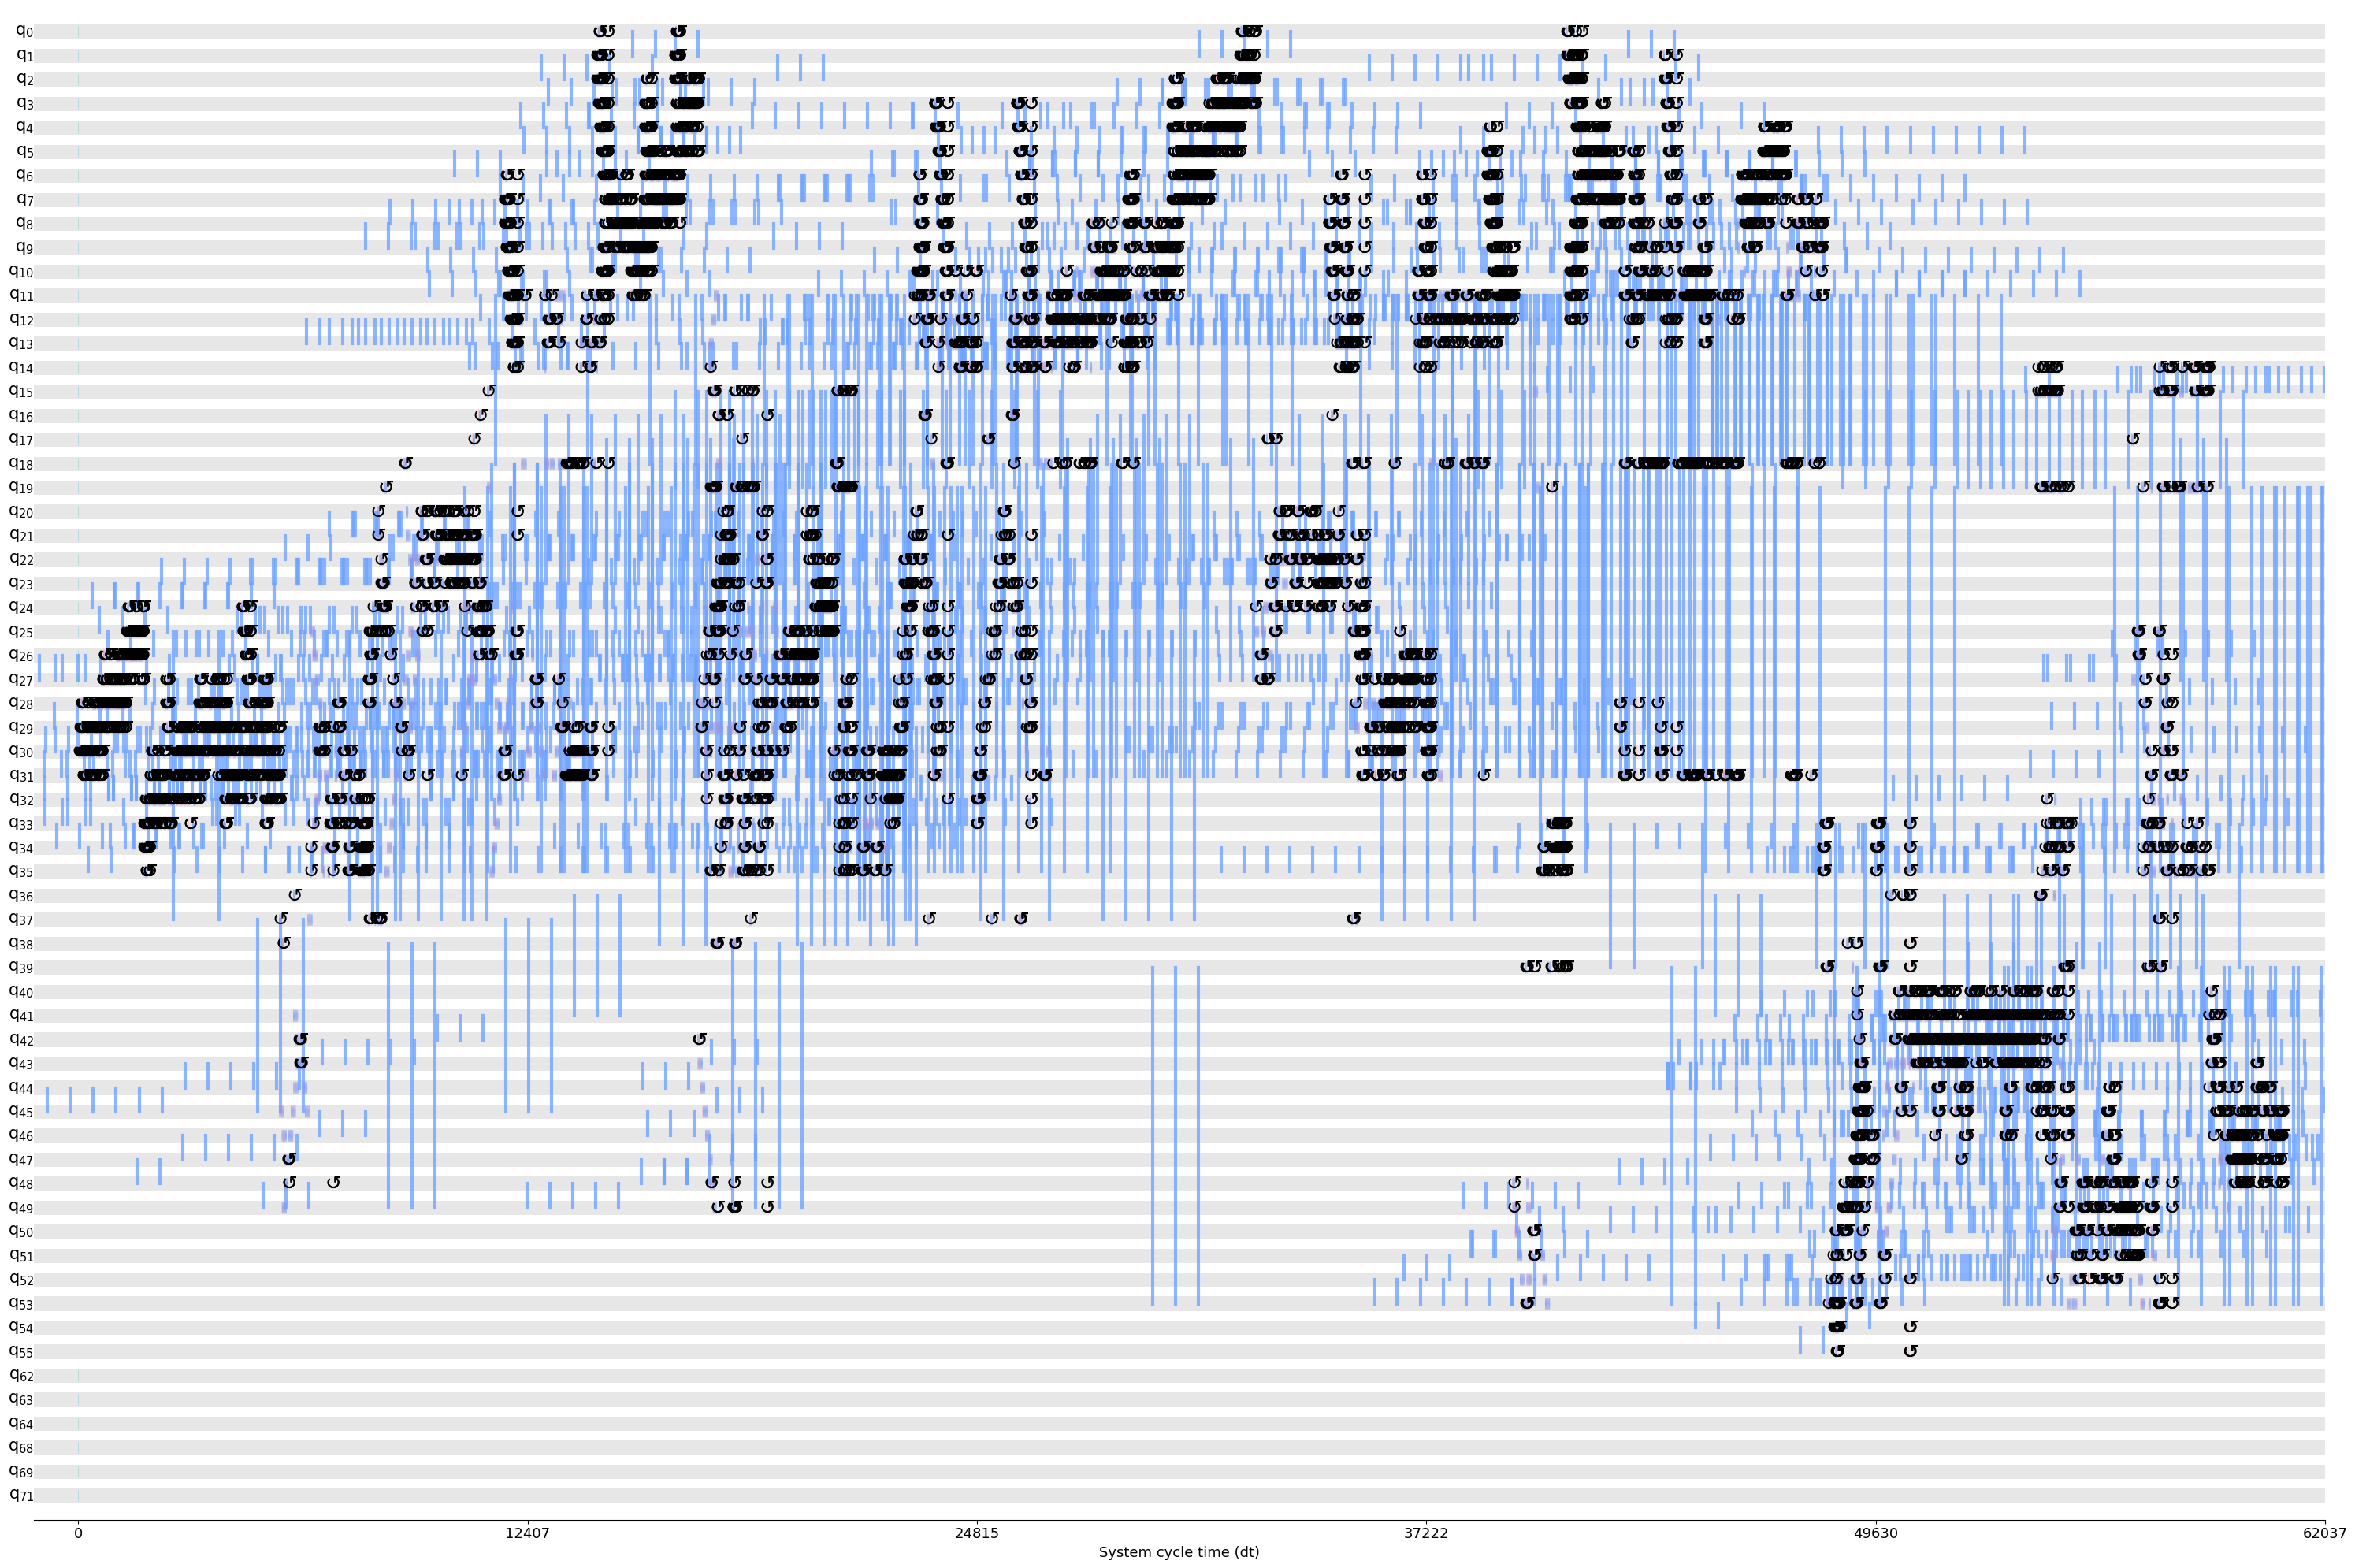

In [193]:
fig, ax = plt.subplots(figsize=(30, 20));

timeline_drawer(circuit, style=IQXSimple(), idle_wires=False, target=computer.target, axis=ax)

## Remove idle qubits and sample

In [194]:
idle_qubit_bools, ckt_no_idle = remove_idle(mapped_circuit)
print(ckt_no_idle.num_qubits)
num_idle = len(idle_qubit_bools)
print(f"Removed {num_idle} idle qubits out of {circuit.num_qubits}.")
print(idle_qubit_bools)

56
Removed 16 idle qubits out of 72.
{62: True, 63: True, 64: True, 68: True, 69: True, 71: True, 56: False, 57: False, 58: False, 59: False, 60: False, 61: False, 65: False, 66: False, 67: False, 70: False}


In [195]:
idle_qubit_indices = sorted(list(idle_qubit_bools.keys()))
all_qubit_indices = sorted([q._index for q in mapped_circuit.qubits])
active_qubit_indices = list(set(all_qubit_indices) - set(idle_qubit_indices))
active_qubit_indices = sorted(active_qubit_indices)
print(f"Active qubits: {active_qubit_indices}")
print(f"Idle qubits: {idle_qubit_indices}")

Active qubits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55]
Idle qubits: [56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]


In [196]:
print(len(active_qubit_indices + idle_qubit_indices))

72


In [197]:
mapped_circuit.measure_all()
ckt_no_idle.measure_all()

In [198]:
print(mapped_circuit.num_qubits)
print(ckt_no_idle.num_qubits)

72
56


In [199]:
simulator = AerSimulator(method="matrix_product_state")
result_idle = simulator.run(mapped_circuit).result()
counts_idle = result_idle.get_counts(0)
print(counts_idle)
result_no_idle = simulator.run(ckt_no_idle).result()
counts_no_idle = result_no_idle.get_counts(0)
print(counts_no_idle)

{'101100011100000000000000001100100100000110111111111111110010110111111100': 1, '101100011100000000000000001100100100000110111111111111111110110011011100': 1023}
{'00000000001100100100000110001111111111111110110011111110': 2, '00000000001100100100000110111111111111110010110111111100': 1, '00000000001100100100000110111111111111111111001011011100': 1, '00000000001100000000000110111111111111111111111011011100': 2, '00000000001100100100000110111111111111111110000011111110': 1, '00000000001100000000000110111111111111111110110011111110': 1, '00000000001100100100000110111111111111111110110011011100': 1016}


In [200]:
def insert_fixed_bools_into_bit_array(active_qubit_indices: List[int], bit_array: BitArray, idle_bools: Dict[int, bool]) -> BitArray:
    """Insert the idle booleans into a bit array."""

    bool_array = bit_array.to_bool_array()
    bool_array_flipped = np.flip(bool_array, 1)
    bool_array_inserted = merge_idle_bits(active_qubit_indices, bool_array_flipped, idle_bools)
    bool_array_inserted_flipped = np.flip(bool_array_inserted, 1)
    return BitArray.from_bool_array(bool_array_inserted_flipped)

In [201]:
bit_array_idle = BitArray.from_counts(counts_idle, num_bits=mapped_circuit.num_qubits)
bit_array_no_idle = BitArray.from_counts(counts_no_idle, num_bits=ckt_no_idle.num_qubits)
print(bit_array_idle.num_bits)
print(bit_array_no_idle.num_bits)

72
56


In [202]:
bit_array_no_idle_inserted = insert_fixed_bools_into_bit_array(active_qubit_indices, bit_array_no_idle, idle_qubit_bools)
bool_array_no_idle = bit_array_idle.to_bool_array()
bool_array_idle = bit_array_no_idle_inserted.to_bool_array()

In [203]:
def bool_list_to_int(bool_list: List[bool]) -> int:
    """Convert a list of boolean to an int,
    e.g. [1, 0, 1] -> 5."""

    bool_str = ''.join(['1' if b else '0' for b in bool_list])
    return int(bool_str, 2)


def bool_array_to_int_list(bool_array: np.ndarray) -> List[int]:
    """Convert each row of a boolean array to an integer."""

    ints = []
    for row in bool_array:
        ints.append(bool_list_to_int(row.tolist()))
    return ints

In [204]:
print(circuit.num_qubits)
bit_array_original = BitArray.from_counts(counts_original, num_bits=circuit.num_qubits)
bool_array_original = bit_array_original.to_bool_array()
print(bool_array_original.shape)
ints_original = bool_array_to_int_list(bool_array_original)

72
(1024, 72)


In [205]:
ints_idle = bool_array_to_int_list(bool_array_idle)
ints_no_idle = bool_array_to_int_list(bool_array_no_idle)

In [206]:
counter_original = Counter(ints_original)

In [207]:
counter_idle = Counter(ints_idle)
counter_no_idle = Counter(ints_no_idle)

In [208]:
print("Original")
for k, v in counter_original.items():
    print(f"{k:b}", v)
print("Idle")
for k, v in counter_idle.items():
    print(f"{k:b}", v)
print("No idle")
for k, v in counter_no_idle.items():
    print(f"{k:b}", v)

Original
101100011100000000000000001100100100000110111111111111111110110111010001 1
101100011100000000000000000000100100000110111111111111111110110011011111 1
101100011100000000000000010000110100000110111111111111111110110011011100 1
101100011100000000000000001100100100000000111111111111111110110011111110 1
101100011100000000000000001100100100000110111111111111111110110011011100 1020
Idle
101100011100000000000000001100100100000110001111111111111110110011111110 2
101100011100000000000000001100100100000110111111111111110010110111111100 1
101100011100000000000000001100100100000110111111111111111111001011011100 1
101100011100000000000000001100000000000110111111111111111111111011011100 2
101100011100000000000000001100100100000110111111111111111110000011111110 1
101100011100000000000000001100000000000110111111111111111110110011111110 1
101100011100000000000000001100100100000110111111111111111110110011011100 1016
No idle
101100011100000000000000001100100100000110111111111111110010110111111100

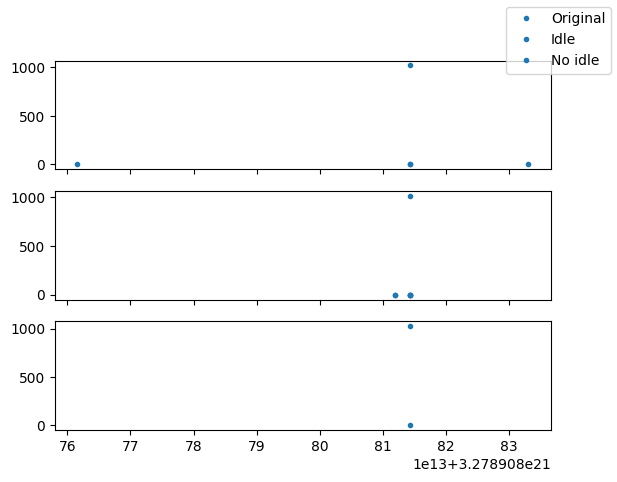

In [212]:
fig, ax = plt.subplots(3, 1, sharex=True)
ax[0].plot(counter_original.keys(), counter_original.values(), '.', label="Original")
ax[1].plot(counter_idle.keys(), counter_idle.values(), '.', label="Idle")
ax[2].plot(counter_no_idle.keys(), counter_no_idle.values(), '.', label="No idle")
fig.legend()